# Preprocessing — well detection, cropping, and the split

**Stage 1 of the pipeline.** Turns raw well-plate photographs into circular
single-well crops, then defines the train/test split every model uses.

| | |
|---|---|
| Classes | pH 5, 6, 7, 8 |
| Wells | 48 per pH → **192 physical wells** |
| Timepoints | 0, 24, 30, 48, 72, 95, 120, 168, 192, 216, 264 hr |
| Condition | Hydrolytic only |
| Raw images | 2,112 = 11 × 4 × 48 |

In [1]:
import os, re, csv, random, warnings
from collections import defaultdict, Counter
import numpy as np, cv2
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"]=110

RAW="New MLPR Data"; CROPS="Preprocessed_Data"
print("raw images   :", sum(1 for d,_,f in os.walk(RAW) for x in f if x.lower().endswith(".jpg")))
print("cropped      :", sum(1 for d,_,f in os.walk(CROPS) for x in f if x.lower().endswith((".jpg",".png"))))

raw images   : 2112
cropped      : 2091


## 1. Well detection

The gel well is isolated so the model sees gel colour, not plate background or labels.

`HSV mask → blur → morphological close/open → contours → circularity filter → circular crop`

Gel colour shifts with both pH and degradation time, so a single HSV range loses
wells at the extremes. Several ranges are tried in order.

In [2]:
GREEN_RANGES=[((10,20,100),(60,200,255)), ((20,20,100),(70,255,255)),
              ((35,90,80),(75,255,255)), ((55,30,40),(75,110,120)), ((65,100,50),(85,255,255))]
MIN_AREA, MIN_RADIUS, MIN_CIRC = 5000, 30, 0.6

def find_well(image, blur=5, kernel=7):
    hsv=cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    for lo,hi in GREEN_RANGES:
        mask=cv2.inRange(hsv,np.array(lo),np.array(hi))
        mask=cv2.GaussianBlur(mask,(blur,blur),0)
        k=np.ones((kernel,kernel),np.uint8)
        mask=cv2.morphologyEx(mask,cv2.MORPH_CLOSE,k)
        mask=cv2.morphologyEx(mask,cv2.MORPH_OPEN,k)
        cnts,_=cv2.findContours(mask,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
        best=None; best_r=0
        for c in cnts:
            area=cv2.contourArea(c)
            if area<MIN_AREA: continue
            (x,y),r=cv2.minEnclosingCircle(c)
            circ=(4*np.pi*area)/(cv2.arcLength(c,True)**2+1e-5)
            if r>best_r and r>MIN_RADIUS and circ>MIN_CIRC:
                best_r=r; best=(int(x),int(y),int(r))
        if best: return best, mask
    return None, mask

def crop(image, well):
    x,y,r=well; h,w=image.shape[:2]
    circle=np.zeros((h,w),np.uint8); cv2.circle(circle,(x,y),r,255,-1)
    masked=cv2.bitwise_and(image,image,mask=circle)
    return masked[max(y-r,0):min(y+r,h), max(x-r,0):min(x+r,w)]

### Worked example — each stage of the crop

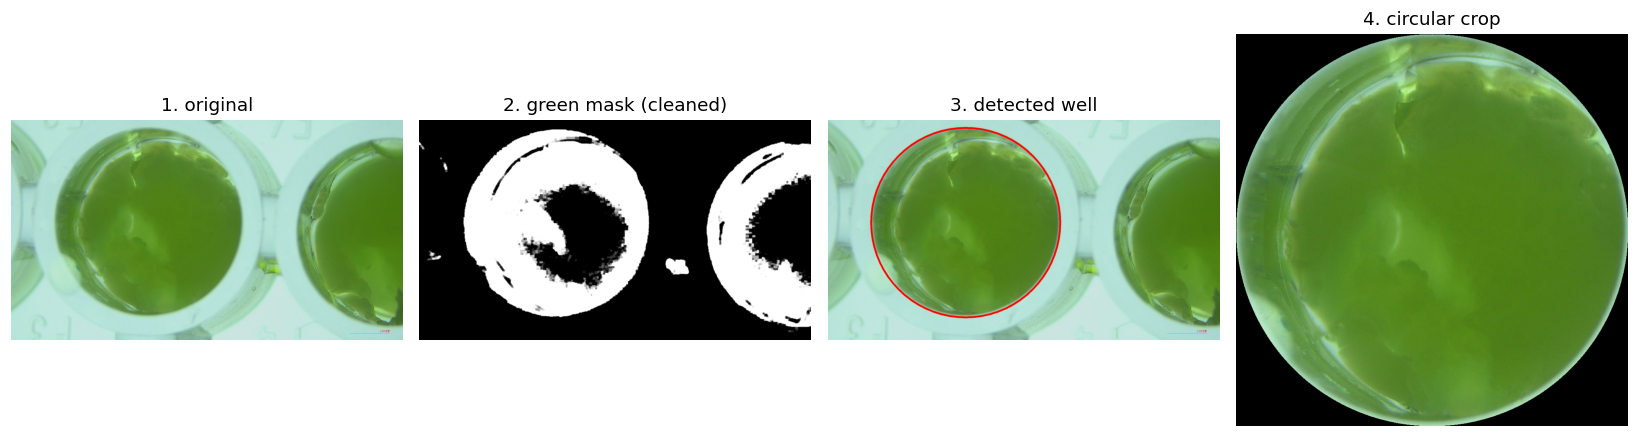

In [3]:
sample="New MLPR Data/48 hr/pH6 Hydrolytic/48hr_pH6_W3.JPG"
img=cv2.imread(sample); well,mask=find_well(img)
out=img.copy()
if well: cv2.circle(out,(well[0],well[1]),well[2],(0,0,255),8)
fig,ax=plt.subplots(1,4,figsize=(15,4))
for a,(im,t) in zip(ax,[(cv2.cvtColor(img,cv2.COLOR_BGR2RGB),"1. original"),
                        (mask,"2. green mask (cleaned)"),
                        (cv2.cvtColor(out,cv2.COLOR_BGR2RGB),"3. detected well"),
                        (cv2.cvtColor(crop(img,well),cv2.COLOR_BGR2RGB),"4. circular crop")]):
    a.imshow(im, cmap="gray" if im.ndim==2 else None); a.set_title(t); a.axis("off")
plt.tight_layout(); plt.show()

### Crop coverage

With the saturation fallback in place, **2,091 of 2,112 images (99.0%)** yield a
crop. The green-range detector alone reaches 92.9%; the fallback recovers 128 of
the remaining 149, concentrated at 0 hr and the late timepoints.

To regenerate `Preprocessed_Data/` from the raw images set `RUN_FULL_CROP = True`
(takes several minutes). The summary below reads the existing output.

In [4]:
RUN_FULL_CROP = False
if RUN_FULL_CROP:
    ok=0; fail=[]
    for dp,_,fns in os.walk(RAW):
        for fn in sorted(fns):
            if not fn.lower().endswith((".jpg",".jpeg",".png")): continue
            im=cv2.imread(os.path.join(dp,fn))
            w=find_well_robust(im) if im is not None else None
            if w is None: fail.append(fn); continue
            dest=os.path.join(CROPS,os.path.relpath(dp,RAW)); os.makedirs(dest,exist_ok=True)
            cv2.imwrite(os.path.join(dest,f"cropped_{fn}"), crop(im,w)); ok+=1
    print(f"cropped {ok}, not recovered {len(fail)}")

raw 2112 | cropped 2091 | not recovered 21 (1.0%)


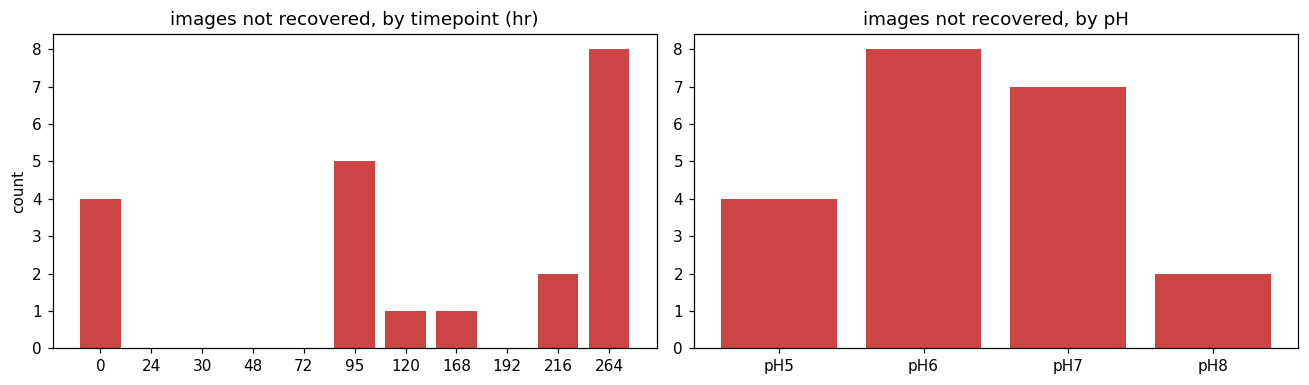

Recovery is lowest at 0 hr (palest gels) and 216/264 hr (darkest),
so the freshest and most degraded states are slightly under-represented.


In [5]:
def scan(root,pat):
    s=set()
    for dp,_,fns in os.walk(root):
        for fn in fns:
            m=re.match(pat,fn)
            if m: s.add(tuple(int(g) for g in m.groups()))
    return s
raw=scan(RAW, r'(\d+)hr_pH(\d+)_W(\d+)\.')
pre=scan(CROPS, r'cropped_(\d+)hr_pH(\d+)_W(\d+)\.')
missing=raw-pre
print(f"raw {len(raw)} | cropped {len(pre)} | not recovered {len(missing)} ({100*len(missing)/len(raw):.1f}%)")

hours=sorted({h for h,_,_ in raw}); byhr=Counter(h for h,_,_ in missing); byph=Counter(p for _,p,_ in missing)
fig,ax=plt.subplots(1,2,figsize=(12,3.6))
ax[0].bar([str(h) for h in hours],[byhr.get(h,0) for h in hours],color="#c44")
ax[0].set_title("images not recovered, by timepoint (hr)"); ax[0].set_ylabel("count")
ax[1].bar([f"pH{p}" for p in (5,6,7,8)],[byph.get(p,0) for p in (5,6,7,8)],color="#c44")
ax[1].set_title("images not recovered, by pH")
plt.tight_layout(); plt.show()
print("Recovery is lowest at 0 hr (palest gels) and 216/264 hr (darkest),")
print("so the freshest and most degraded states are slightly under-represented.")

## 2. The split — grouped by physical well

Each well is photographed at **11 timepoints**, so the 11 images of one gel are
near-duplicates of each other. The unit of the split is therefore the physical
well: every image of a well goes to the same side, which keeps the evaluation
measuring generalisation to new gels rather than recall of familiar ones.

**A W-number alone does not identify a well.** W-numbers restart at 1 for each
pH, so `W13` names four different gels. The physical well is the `(pH, well)`
pair — 192 in total.

In [6]:
SEED=42; RATIO=(0.60,0.20,0.20)
rows=[]
for dp,_,fns in os.walk(CROPS):
    for fn in fns:
        m=re.match(r'cropped_(\d+)hr_pH(\d+)_W(\d+)\.',fn,re.I)
        if m:
            hour,ph,w=(int(g) for g in m.groups())
            rows.append(dict(path=os.path.join(dp,fn),pH=ph,well=w,hour=hour))

wells=defaultdict(list)
for r in rows: wells[(r["pH"],r["well"])].append(r)
by_ph=defaultdict(list)
for k in wells: by_ph[k[0]].append(k)

rng=random.Random(SEED); assign={}
for ph,keys in sorted(by_ph.items()):
    keys=sorted(keys); rng.shuffle(keys); n=len(keys)
    n_tr=int(round(RATIO[0]*n)); n_va=int(round(RATIO[1]*n))
    for k in keys[:n_tr]: assign[k]="train"
    for k in keys[n_tr:n_tr+n_va]: assign[k]="val"
    for k in keys[n_tr+n_va:]: assign[k]="test"
for r in rows: r["split"]=assign[(r["pH"],r["well"])]

with open("preprocessing/splits.csv","w",newline="") as f:
    w=csv.DictWriter(f,fieldnames=["path","pH","well","hour","split"]); w.writeheader()
    w.writerows(sorted(rows,key=lambda r:(r["split"],r["pH"],r["well"],r["hour"])))
print(f"{len(rows)} images, {len(wells)} physical wells -> preprocessing/splits.csv")

2091 images, 192 physical wells -> preprocessing/splits.csv


In [7]:
seen=defaultdict(set)
for r in rows:
    seen[r["split"]].add((r["pH"], r["well"]))

for s in ("train","val","test"):
    imgs=[r for r in rows if r["split"]==s]
    dist={p: sum(1 for r in imgs if r["pH"]==p) for p in (5,6,7,8)}
    print(f"  {s:5s} wells={len(seen[s]):3d}  images={len(imgs):4d}  per-pH={dist}")

for a,b in (("train","val"),("train","test"),("val","test")):
    ov=seen[a]&seen[b]
    print(f"  well overlap {a}&{b}: {len(ov)}")
    assert not ov, "a well appears in more than one split"
print()
print("Verified: no physical well appears in more than one split.")

  train wells=116  images=1264  per-pH={5: 318, 6: 314, 7: 315, 8: 317}
  val   wells= 40  images= 435  per-pH={5: 109, 6: 109, 7: 107, 8: 110}
  test  wells= 36  images= 392  per-pH={5: 97, 6: 97, 7: 99, 8: 99}
  well overlap train&val: 0
  well overlap train&test: 0
  well overlap val&test: 0

Verified: no physical well appears in more than one split.


---
**Output:** `preprocessing/splits.csv` — the manifest every model reads.

Models are evaluated with `StratifiedGroupKFold(5)` grouped by well, which uses
every well as test data exactly once. The 60/20/20 columns above provide a fixed
holdout for the train/validation gap shown in `supervised/`.